# Explainable Inverse Design Analysis of Couplers

This notebook demonstrates how to use the `squadds.ml` module to analyze the `coupler-CapNInterdigitalTee-cap_matrix` dataset. 

We will:
1. Load the curated dataset.
2. Use **Explainable Boosting Machines (EBM)** to identify the key geometric parameters (features) that drive each capacitance (target).
3. Use **Symbolic Regression (PySR)** to derive analytical equations for these capacitances.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from squadds.ml.pipeline import SQuADDSAnalysisPipeline
from squadds.ml.utils import prepare_features_with_interactions

 /Users/shanto/LFL/SQuADDS_Refactor/.venv/lib/python3.11/site-packages/tqdm/auto.py: 21

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## 1. Load Data
Load the curated dataset containing geometry parameters and simulated capacitance values.

In [2]:
# Load dataset
df = pd.read_csv("../coupler_capacitance_data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (430, 10)


,cap_gap,cap_width,finger_count,finger_length,bottom_to_bottom,bottom_to_ground,ground_to_ground,top_to_bottom,top_to_ground,top_to_top
0,2.1,4.9,1.0,25.9,12.78614,12.09846,58.45017,0.51663,14.95437,15.65491
1,2.1,10.9,8.0,45.9,94.96956,58.07364,124.18885,36.28408,29.22434,65.85844
2,4.1,6.9,2.0,35.9,21.94864,18.77498,66.60369,2.88026,15.65588,18.77838
3,2.1,6.9,6.0,45.9,55.18578,33.69106,88.75992,21.05076,20.98596,42.46632
4,4.1,8.9,6.0,45.9,60.57606,41.62987,101.33585,18.40010,24.77954,43.49158


## 2. Define Features and Targets
We identified the varying design parameters in the previous step.

In [3]:
features = ['cap_gap', 'cap_width', 'finger_count', 'finger_length']
targets = ['bottom_to_bottom', 'bottom_to_ground', 'ground_to_ground', 
           'top_to_bottom', 'top_to_ground', 'top_to_top']

### 2.1 Visualize Dataset
Let's look at the distribution of our design parameters and target capacitances.

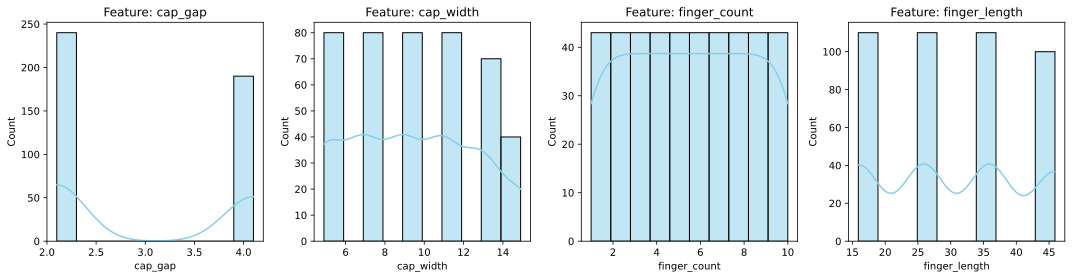

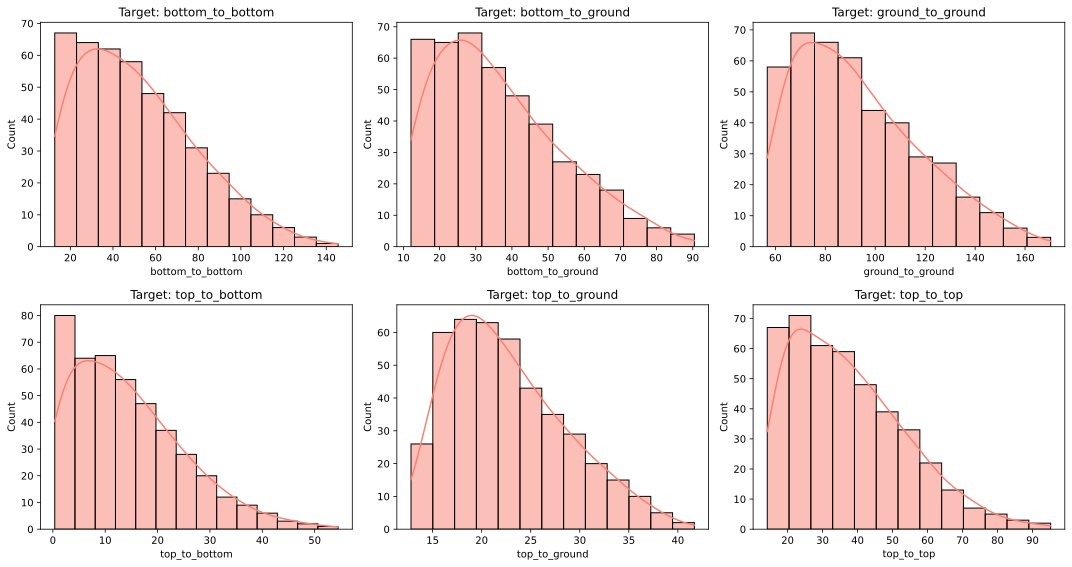

In [4]:
def plot_dataset_distributions(df, features, targets):
    # Plot features
    plt.figure(figsize=(15, 4))
    for i, col in enumerate(features):
        plt.subplot(1, 4, i+1)
        sns.histplot(df[col], kde=True, color='skyblue')
        plt.title(f'Feature: {col}')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()
    
    # Plot targets
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(targets):
        plt.subplot(2, 3, i+1)
        sns.histplot(df[col], kde=True, color='salmon')
        plt.title(f'Target: {col}')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()

plot_dataset_distributions(df, features, targets)

## 3. Run Analysis Pipeline
We run the analysis for each target. The pipeline will:
- Train an EBM to find important features and interactions.
- Feed those features to PySR to find analytical equations.

**Note:** For demonstration speed, we limit PySR iterations (`niterations=20`). Increase this value (e.g., to 100) for more accurate and robust equations.

In [ ]:
pipeline = SQuADDSAnalysisPipeline(random_state=42)

# Output dictionary to store results
results = pipeline.analyze(
    df,
    features,
    targets,
    test_size=0.1,
    # EBM params
    ebm_kwargs={'interactions': 5, 'outer_bags': 4, 'inner_bags': 0},
    # PySR params - keep low for demo, increase for production
    symbolic_kwargs={
        'niterations': 20, 
        'populations': 15, 
        'population_size': 33,
        'maxsize': 25,
    },
    feature_threshold=0.01
)

INFO:interpret.utils._native:EBM lib loading.
INFO:interpret.utils._native:Finding library for Darwin, arm64, bitsize=64, debug=False
INFO:interpret.utils._native:Loading EBM library /Users/shanto/LFL/SQuADDS_Refactor/.venv/lib/python3.11/site-packages/interpret/utils/../root/bld/lib/libebm_mac_arm.dylib
INFO:interpret.utils._compressed_dataset:Creating native dataset


Analyzing target: bottom_to_bottom...
  Training EBM for feature selection...


INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST
 /Users/shanto/LFL/SQuADDS_Refactor/.venv/lib/python3.11/site-packages/pysr/sr.py: 2811Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...


  Selected features: ['cap_gap', 'finger_length', 'cap_width', 'finger_count']
  Selected interactions: [('cap_gap', 'finger_count'), ('cap_width', 'finger_count'), ('finger_count', 'finger_length')]
  Training Symbolic Regressor...


## 4. View Results
### Best Equations

In [ ]:
# Print all equations without truncation
for t, r in results.items():
    print(f"{t:<20} | R2: {r['symbolic_metrics']['r2']:.4f}")
    print(f"Eq: {r['best_equation']}")
    print("-" * 80)

### Feature Importance (EBM)
Visualizing the contribution of each feature to the target capacitance.

In [ ]:
def plot_ebm_feature_importance(results, target_name):
    if target_name not in results:
        return
    
    res = results[target_name]
    # Access internal InterpretML model from EBMAnalyzer wrapper
    ebm = res['ebm_model'].model  
    
    # Get importances and term names
    term_importances = ebm.term_importances()
    term_names = ebm.term_names_
    
    # Sort by importance
    indices = np.argsort(term_importances)[::-1]
    top_n = min(10, len(indices))
    top_indices = indices[:top_n]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), term_importances[top_indices], align='center', color='teal')
    plt.yticks(range(top_n), [term_names[i] for i in top_indices])
    plt.gca().invert_yaxis()
    plt.xlabel('Mean Absolute Score (Contribution)')
    plt.title(f'EBM Feature Importance: {target_name}')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot for top 2 targets
plot_ebm_feature_importance(results, 'top_to_bottom')
plot_ebm_feature_importance(results, 'bottom_to_bottom')

### Pareto Front (PySR)
Visualizing the trade-off between equation complexity and accuracy (loss).

In [ ]:
def plot_pareto_front(results, target_name):
    if target_name not in results:
        return
        
    res = results[target_name]
    sym_reg = res['symbolic_model']
    
    # Get equations dataframe from SymbolicRegressor wrapper
    equations = sym_reg.get_equations()
    
    plt.figure(figsize=(10, 6))
    plt.scatter(equations['complexity'], equations['loss'], c='steelblue', s=50, label='Candidate Models')
    
    # Highlight best model selected by PySR
    best_eqn_str = res['best_equation']
    # Handle potential differences in string formatting if necessary, but exact match usually works
    # Alternatively, PySR's equations dataframe often has a 'selection' column implied by model choice logic
    # Here we just match the string equation
    best_row = equations[equations['equation'] == best_eqn_str]
    
    if not best_row.empty:
        plt.scatter(best_row['complexity'], best_row['loss'], c='red', s=100, marker='*', label='Best Model')
    
    plt.xlabel('Complexity')
    plt.ylabel('Loss (MSE)')
    plt.yscale('log')
    plt.title(f'PySR Pareto Front: {target_name}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Plot for top 2 targets
plot_pareto_front(results, 'top_to_bottom')
plot_pareto_front(results, 'bottom_to_bottom')

### Parity Plots
Visualizing the agreement between the Symbolic Regression model predictions and the true data.

In [ ]:
def plot_parity(results, df, target_name):
    if target_name not in results:
        return
    
    res = results[target_name]
    sym_model = res['symbolic_model']
    
    # Get features
    base_feats = res['selected_features']
    inte_pairs = res['interaction_pairs']
    
    # Prepare X
    X_all = df[features]
    X_sym = prepare_features_with_interactions(X_all, base_feats, inte_pairs)
    
    # Predict
    y_pred = sym_model.predict(X_sym)
    y_true = df[target_name]
    
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, edgecolor='k')
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Identity')
    
    plt.xlabel(f"True {target_name}")
    plt.ylabel(f"Predicted {target_name}")
    plt.title(f"Parity Plot: {target_name}\nR2: {res['symbolic_metrics']['r2']:.4f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot for top 2 targets
plot_parity(results, df, 'top_to_bottom')
plot_parity(results, df, 'bottom_to_bottom')